In [ ]:
from google.colab import files

uploaded = files.upload()

In [7]:
import os

print(os.listdir())

['.config', 'archive.zip', 'archive (1).zip', 'sample_data']


In [8]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

In [9]:
import os

print(os.listdir('dataset'))

['ai4i_predictive_maintenance.csv']


In [10]:
import pandas as pd

df = pd.read_csv('dataset/ai4i_predictive_maintenance.csv')

In [11]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,L70598,L,297.9,307.1,1525,20.3,238,0,0,0,0,0,0
1,2,H76399,H,298.6,307.8,1384,32.3,249,0,0,0,0,0,0
2,3,M37684,M,305.0,314.1,1958,36.3,67,0,0,0,0,0,0
3,4,L78591,L,300.3,309.7,1009,46.8,248,1,0,0,0,1,0
4,5,L87722,L,300.7,311.6,1863,38.6,133,0,0,0,0,0,0


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df=pd.read_csv("dataset/ai4i_predictive_maintenance.csv")

In [14]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,L70598,L,297.9,307.1,1525,20.3,238,0,0,0,0,0,0
1,2,H76399,H,298.6,307.8,1384,32.3,249,0,0,0,0,0,0
2,3,M37684,M,305.0,314.1,1958,36.3,67,0,0,0,0,0,0
3,4,L78591,L,300.3,309.7,1009,46.8,248,1,0,0,0,1,0
4,5,L87722,L,300.7,311.6,1863,38.6,133,0,0,0,0,0,0


In [15]:
os.listdir('dataset')

['ai4i_predictive_maintenance.csv']

In [16]:
df.shape

(10000, 14)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [18]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9362
1,638


In [19]:
df['Machine failure'].value_counts(normalize=True)*100

,proportion
Machine failure,
0,93.62
1,6.38


In [20]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.017530,310.011220,1537.441000,39.909650,124.080200,0.063800,0.015400,0.015800,0.002200,0.033900,0.001000
std,2886.89568,2.009803,2.263866,179.389422,9.926393,72.063675,0.244409,0.123144,0.124707,0.046855,0.180981,0.031609
min,1.00000,292.300000,301.100000,887.000000,2.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2500.75000,298.600000,308.500000,1414.000000,33.300000,62.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5000.50000,300.000000,310.000000,1538.000000,40.000000,124.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7500.25000,301.400000,311.600000,1659.000000,46.600000,186.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10000.00000,309.000000,320.500000,2171.000000,77.200000,249.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [21]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


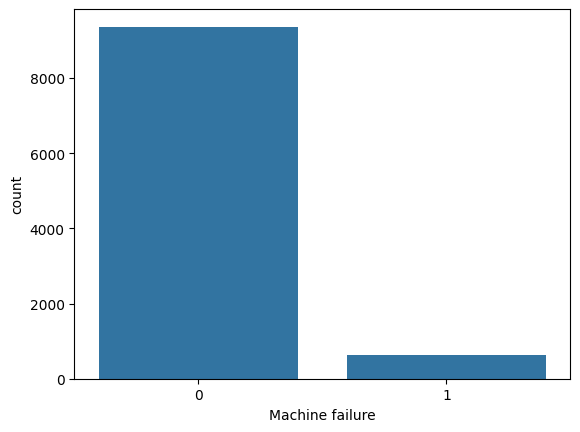

In [22]:
sns.countplot(x='Machine failure', data=df)
plt.show()

In [24]:
df['Type'].value_counts()

,count
Type,
L,6108
M,2931
H,961


In [27]:
df = df.drop(columns=[
    'UDI',
    'Product ID',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
])

In [28]:
df.columns

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Type_L', 'Type_M'],
      dtype='object')

In [33]:
df.columns

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Type_L', 'Type_M'],
      dtype='object')

In [34]:
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(8000, 7)
(2000, 7)
(8000,)
(2000,)


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
print(X_train_scaled[:5])

[[ 0.1441014  -0.26538152  1.24068973 -1.10036119  0.64927958  0.79392948
  -0.63774374]
 [ 0.1441014   0.08796729 -0.77507005  0.11592127 -1.18551595  0.79392948
  -0.63774374]
 [-0.60131492 -0.30955012 -0.23642349 -0.44698631  0.2322806   0.79392948
  -0.63774374]
 [-0.99887029 -1.06041633 -1.40256551  0.31695969  0.51027992 -1.25955771
   1.56802794]
 [-0.5516205  -0.92791053 -0.98608622 -0.74854395 -0.43491778  0.79392948
  -0.63774374]]


In [40]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [41]:
y_pred_lr = lr.predict(X_test_scaled)

In [42]:
print(y_pred_lr[:20])

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1872
           1       0.86      0.24      0.38       128

    accuracy                           0.95      2000
   macro avg       0.91      0.62      0.68      2000
weighted avg       0.94      0.95      0.94      2000



In [44]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [45]:
y_pred_dt = dt.predict(X_test)

In [46]:
print(y_pred_dt[:20])

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1872
           1       0.60      0.66      0.62       128

    accuracy                           0.95      2000
   macro avg       0.79      0.81      0.80      2000
weighted avg       0.95      0.95      0.95      2000



In [51]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [52]:
y_pred_rf = rf.predict(X_test)

In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1872
           1       0.95      0.54      0.69       128

    accuracy                           0.97      2000
   macro avg       0.96      0.77      0.83      2000
weighted avg       0.97      0.97      0.96      2000



In [54]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring='f1'
)

print(scores)
print("Mean F1 Score:", scores.mean())

[0.67692308 0.71568627 0.63917526 0.67346939 0.67980296]
Mean F1 Score: 0.6770113905169932


In [57]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, None]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, None], 'n_estimators': [50, 100]},
             scoring='f1')

In [58]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': None, 'n_estimators': 100}
0.6571570585216903


In [59]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
4,Tool wear [min],0.309174
3,Torque [Nm],0.283466
2,Rotational speed [rpm],0.140627
1,Process temperature [K],0.119911
0,Air temperature [K],0.119250
5,Type_L,0.017570
6,Type_M,0.010002


In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[1868    4]
 [  59   69]]


In [61]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9401166866987181


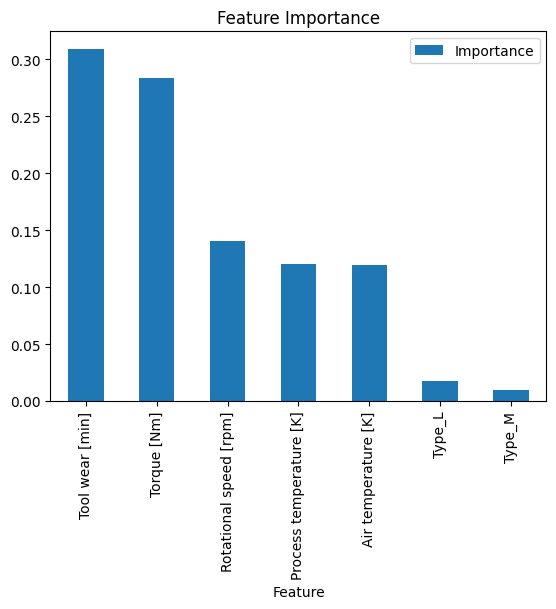

In [62]:
import matplotlib.pyplot as plt

feature_importance.plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.title("Feature Importance")
plt.show()

In [63]:
import joblib

joblib.dump(rf,'predictive_maintenance_model.pkl')

['predictive_maintenance_model.pkl']

In [66]:
sample = pd.DataFrame({
    'Air temperature [K]':[300],
    'Process temperature [K]':[310],
    'Rotational speed [rpm]':[1500],
    'Torque [Nm]':[40],
    'Tool wear [min]':[120],
    'Type_L':[1],
    'Type_M':[0]
})

prediction = rf.predict(sample)

if prediction[0] == 0:
    print("Prediction = 0")
    print("Machine Healthy")
else:
    print("Prediction = 1")
    print("Machine Failure Predicted")

Prediction = 0
Machine Healthy


In [67]:
sample_failure = pd.DataFrame({
    'Air temperature [K]':[305],
    'Process temperature [K]':[315],
    'Rotational speed [rpm]':[2000],
    'Torque [Nm]':[70],
    'Tool wear [min]':[240],
    'Type_L':[1],
    'Type_M':[0]
})

prediction = rf.predict(sample_failure)

if prediction[0] == 0:
    print("Prediction = 0")
    print("Machine Healthy")
else:
    print("Prediction = 1")
    print("Machine Failure Predicted")

Prediction = 1
Machine Failure Predicted
